# Part I - Trip Duration Analysis
## by Gabriela Lopes

## Introduction

> Introduce the dataset

>**Rubric Tip**: Your code should not generate any errors, and should use functions, loops where possible to reduce repetitive code. Prefer to use functions to reuse code statements.

> **Rubric Tip**: Document your approach and findings in markdown cells. Use comments and docstrings in code cells to document the code functionality.

>**Rubric Tip**: Markup cells should have headers and text that organize your thoughts, findings, and what you plan on investigating next.  

## Preliminary Wrangling

In [25]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.

> Note that the collective size of all your files in the current worksapce **must not exceed 1 GB** in total. 


In [26]:
# This data set includes information about individual rides made in a bike-sharing 
#system covering the greater San Francisco Bay area.

df = pd.read_csv('201902-fordgobike-tripdata.csv')

print(df.head())

   duration_sec                start_time                  end_time  \
0         52185  2019-02-28 17:32:10.1450  2019-03-01 08:01:55.9750   
1         42521  2019-02-28 18:53:21.7890  2019-03-01 06:42:03.0560   
2         61854  2019-02-28 12:13:13.2180  2019-03-01 05:24:08.1460   
3         36490  2019-02-28 17:54:26.0100  2019-03-01 04:02:36.8420   
4          1585  2019-02-28 23:54:18.5490  2019-03-01 00:20:44.0740   

   start_station_id                                start_station_name  \
0              21.0  Montgomery St BART Station (Market St at 2nd St)   
1              23.0                     The Embarcadero at Steuart St   
2              86.0                           Market St at Dolores St   
3             375.0                           Grove St at Masonic Ave   
4               7.0                               Frank H Ogawa Plaza   

   start_station_latitude  start_station_longitude  end_station_id  \
0               37.789625              -122.400811            13

In [27]:
print(df.dtypes)

duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object


In [28]:
print(df.shape)

(183412, 16)


In [29]:
print(df.describe())

        duration_sec  start_station_id  start_station_latitude  \
count  183412.000000     183215.000000           183412.000000   
mean      726.078435        138.590427               37.771223   
std      1794.389780        111.778864                0.099581   
min        61.000000          3.000000               37.317298   
25%       325.000000         47.000000               37.770083   
50%       514.000000        104.000000               37.780760   
75%       796.000000        239.000000               37.797280   
max     85444.000000        398.000000               37.880222   

       start_station_longitude  end_station_id  end_station_latitude  \
count            183412.000000   183215.000000         183412.000000   
mean               -122.352664      136.249123             37.771427   
std                   0.117097      111.515131              0.099490   
min                -122.453704        3.000000             37.317298   
25%                -122.412408       44.00000

In [30]:
print(df.columns)

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')


### What is the structure of your dataset?

> The dataset contains 183,412 rows and 16 features. The features are:

>duration_sec: Duration of the trip in seconds.\
start_time: Start time of the trip.\
end_time: End time of the trip.\
start_station_id: ID of the start station.\
start_station_name: Name of the start station.\
start_station_latitude: Latitude of the start station.\
start_station_longitude: Longitude of the start station.\
end_station_id: ID of the end station.\
end_station_name: Name of the end station.\
end_station_latitude: Latitude of the end station.\
end_station_longitude: Longitude of the end station.\
bike_id: ID of the bike used in the trip.\
user_type: Type of user (Customer or Subscriber).\
member_birth_year: Birth year of the member (if available).\
member_gender: Gender of the member (if available).\
bike_share_for_all_trip: Whether the trip was part of the "Bike Share for All" program.\


### What is/are the main feature(s) of interest in your dataset?

> Most variables are numeric in nature

>The primary features of interest are:\
>Trip duration (duration_sec): To analyze the length of trips.\
Start and End Locations (start_station_name, end_station_name): To understand travel patterns and popular stations.\
User demographics (user_type, member_birth_year, member_gender): To analyze who uses the service and their preferences.\

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> The following features are most relevant:

>Trip-related variables:\
duration_sec: For analyzing trip lengths.\
start_time and end_time: To study time patterns in trips (e.g., peak hours).\
\
Location-related variables:\
start_station_name and end_station_name: To identify popular routes.\
start_station_latitude, start_station_longitude, end_station_latitude, end_station_longitude: For geospatial analysis.\
\
Demographic variables:\
user_type: To differentiate between subscribers and one-time customers.\
member_birth_year and member_gender: For user profiling and identifying trends across age groups or genders.\

## Univariate Exploration

> In this section, investigate distributions of individual variables. If you see unusual points or outliers, take a deeper look to clean things up and prepare yourself to look at relationships between variables.

>**Rubric Tip**: Use the "Question-Visualization-Observations" framework  throughout the exploration. This framework involves **asking a question from the data, creating a visualization to find answers, and then recording observations after each visualisation.** 

> **Rubric Tip**: This part (Univariate Exploration) should include at least one histogram, and either a bar chart of count plot.

>**Rubric Tip**: Visualizations should depict the data appropriately so that the plots are easily interpretable. You should choose an appropriate plot type, data encodings, and formatting as needed. The formatting may include setting/adding the title, labels, legend, and comments. Also, do not overplot or incorrectly plot ordinal data.

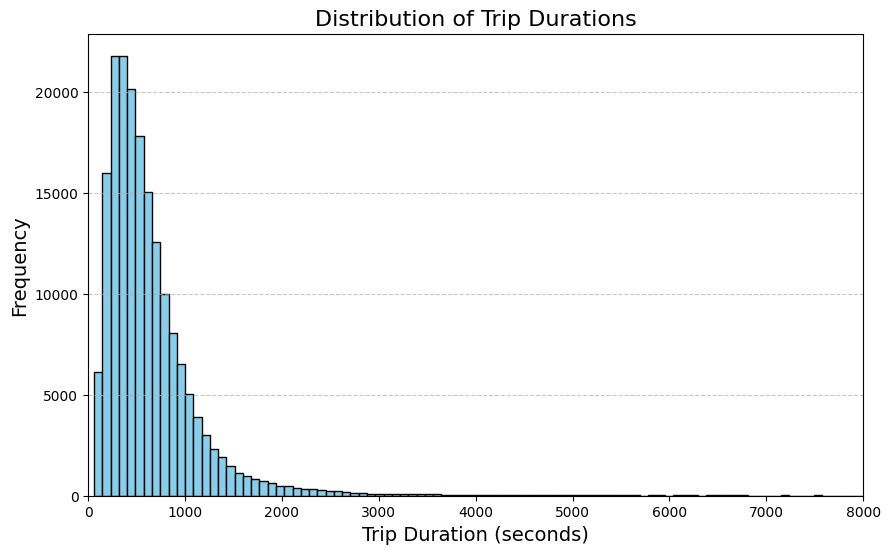

In [31]:
#Question 1: What is the distribution of trip durations?
#Visualization: A histogram pode ser usado para entender a distribuição de duration_sec.

# Plot histogram for trip duration
plt.figure(figsize=(10, 6))
plt.hist(df['duration_sec'], bins=1000, color='skyblue', edgecolor='black')
plt.title('Distribution of Trip Durations', fontsize=16)
plt.xlabel('Trip Duration (seconds)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 8000)
plt.show()

In [32]:
df['duration_sec'].describe()

count    183412.000000
mean        726.078435
std        1794.389780
min          61.000000
25%         325.000000
50%         514.000000
75%         796.000000
max       85444.000000
Name: duration_sec, dtype: float64

### Result: the average of 726.08 seconds is approximately 12.1 minutes.

In [33]:
#Question 2: What is the user type distribution?
#Visualization: Use um gráfico de barras para contar as categorias de user_type.

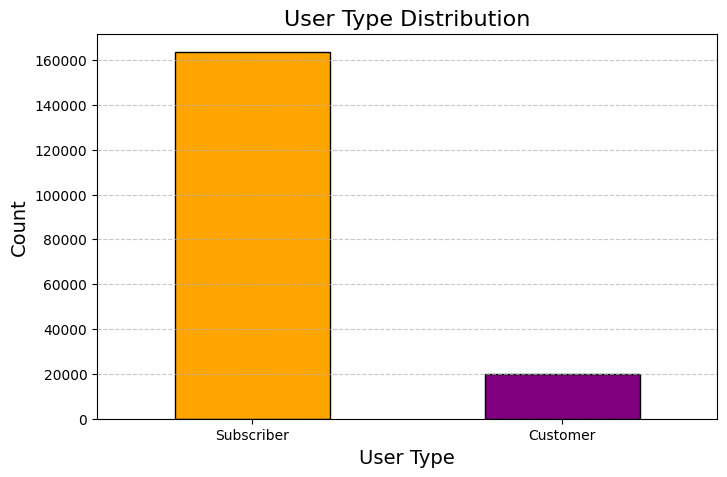

In [34]:
# Plot bar chart for user type
user_counts = df['user_type'].value_counts()

plt.figure(figsize=(8, 5))
user_counts.plot(kind='bar', color=['orange', 'purple'], edgecolor='black')
plt.title('User Type Distribution', fontsize=16)
plt.xlabel('User Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Result: A predominance of subscribers over customs.

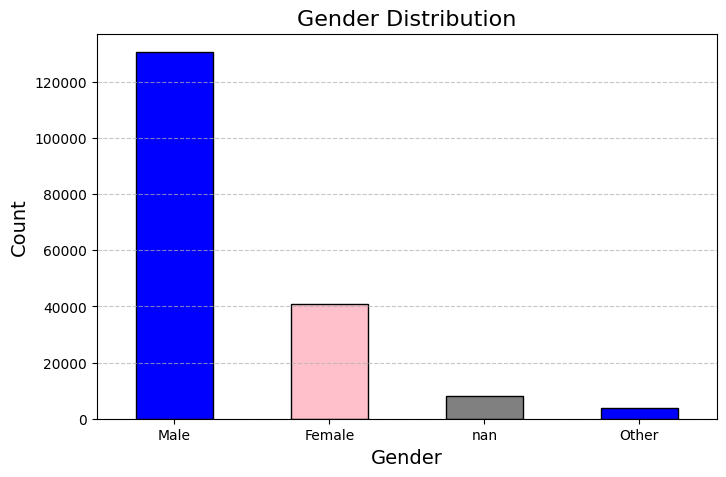

In [35]:
#Question 3: What is the distribution of member genders?
#Visualization: Um gráfico de barras para member_gender.
  
# Plot bar chart for member gender
gender_counts = df['member_gender'].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
gender_counts.plot(kind='bar', color=['blue', 'pink', 'gray'], edgecolor='black')
plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Result: There is a small portion of genders not filled in and others, but the majority of users are male.

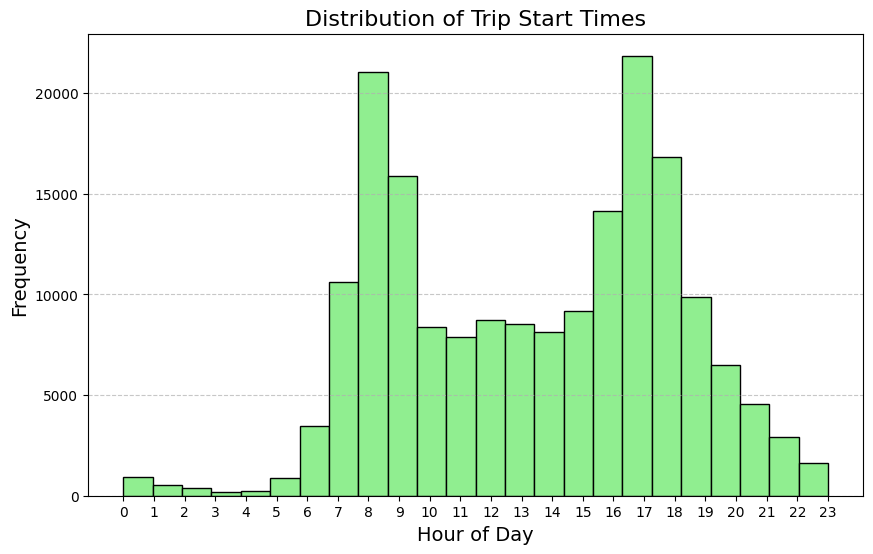

In [36]:
#Question 4: What is the distribution of trip start times?
#Visualization: Um histograma para start_time (após converter para formato datetime e extrair horas).

# Extract hour from start_time and plot histogram
df['start_hour'] = pd.to_datetime(df['start_time']).dt.hour

plt.figure(figsize=(10, 6))
plt.hist(df['start_hour'], bins=24, color='lightgreen', edgecolor='black')
plt.title('Distribution of Trip Start Times', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Result: There are expected patterns with peaks during commuting hours (8-9 AM and 5-6 PM).

3. Start Stations Location (with Legend)
Goal:
The goal of this visualization is to show the geographical distribution of the top 10 most frequented start stations based on trip counts. Instead of overcrowding the scatter plot with station labels, the names of the stations will be displayed in a legend, ensuring the plot remains clean and readable.

Comment:
The scatter plot represents the longitude and latitude of the top 10 start stations, with each station marked by a unique color. The names of the stations are now presented in the legend, making it easier to identify the stations while maintaining a clean layout. This visualization helps in understanding the concentration and spread of bike stations across the city.

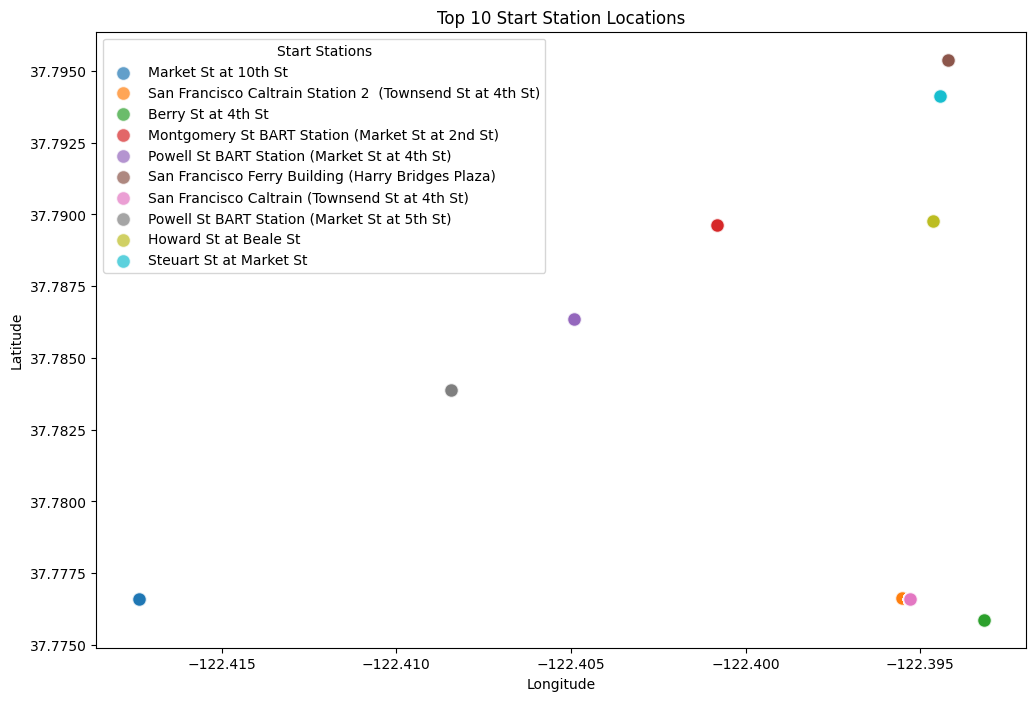

In [37]:
# Top 10 stations by trip frequency
station_counts = df['start_station_name'].value_counts().head(10)
top_stations = station_counts.index

# Filter the dataset for the top 10 stations
df_top_stations = df[df['start_station_name'].isin(top_stations)]

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a scatter plot for each top station with a unique color
for station in top_stations:
    station_data = df_top_stations[df_top_stations['start_station_name'] == station]
    plt.scatter(station_data['start_station_longitude'], 
                station_data['start_station_latitude'], 
                label=station,  # Label the station for the legend
                alpha=0.7, 
                edgecolors='w', 
                s=100)  # Adjust size for better visibility

# Set titles and labels
plt.title('Top 10 Start Station Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add legend to the plot
plt.legend(title="Start Stations", loc='upper left', fontsize=10)

# Show the plot
plt.show()

## Cleaning

In [38]:
# Filtrando o DataFrame para manter apenas as linhas onde a duração é menor ou igual a 769.000
df_cleaned = df[df['duration_sec'] <= 769.000000]

# Exibindo as primeiras linhas do DataFrame para verificar
df_cleaned.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_hour
10,458,2019-02-28 23:57:57.2110,2019-03-01 00:05:35.4350,370.0,Jones St at Post St,37.787327,-122.413278,43.0,San Francisco Public Library (Grove St at Hyde...,37.778768,-122.415929,5318,Subscriber,1996.0,Female,Yes,23
11,506,2019-02-28 23:56:55.5400,2019-03-01 00:05:21.7330,44.0,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,343.0,Bryant St at 2nd St,37.783172,-122.393572,5848,Subscriber,1993.0,Male,No,23
14,395,2019-02-28 23:56:26.8480,2019-03-01 00:03:01.9470,243.0,Bancroft Way at College Ave,37.869360,-122.254337,252.0,Channing Way at Shattuck Ave,37.865847,-122.267443,4786,Subscriber,1988.0,Male,No,23
15,208,2019-02-28 23:59:18.5480,2019-03-01 00:02:47.2280,349.0,Howard St at Mary St,37.781010,-122.405666,60.0,8th St at Ringold St,37.774520,-122.409449,6361,Subscriber,1993.0,Male,Yes,23
16,548,2019-02-28 23:50:41.6070,2019-02-28 23:59:49.9530,131.0,22nd St at Dolores St,37.755000,-122.425728,71.0,Broderick St at Oak St,37.773063,-122.439078,6572,Subscriber,1981.0,Male,No,23


In [39]:
# Se quiser verificar o resultado da descrição após a limpeza
df_cleaned.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,start_hour
count,134395.000000,134279.000000,134395.000000,134395.000000,134279.000000,134395.000000,134395.000000,134395.000000,129083.000000,134395.000000
mean,419.822121,140.215328,37.769025,-122.344490,137.198363,37.769084,-122.344138,4459.614993,1984.945113,13.472785
std,175.801015,109.856949,0.107807,0.124291,108.914802,0.107717,0.123896,1662.128675,10.019039,4.784267
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1900.000000,0.000000
25%,278.000000,50.000000,37.770407,-122.411647,47.000000,37.771058,-122.410662,3777.000000,1980.000000,9.000000
50%,409.000000,104.000000,37.780955,-122.397086,102.000000,37.780955,-122.395526,4945.000000,1987.000000,14.000000
75%,559.000000,239.000000,37.798572,-122.271738,238.000000,37.799953,-122.272080,5491.000000,1992.000000,17.000000
max,769.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000,23.000000


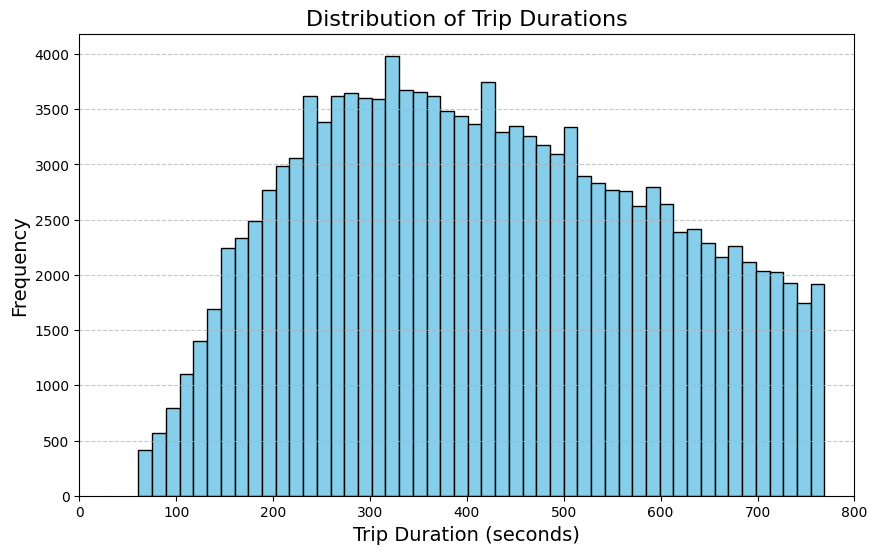

In [40]:
# Plot histogram for trip duration
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['duration_sec'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Trip Durations', fontsize=16)
plt.xlabel('Trip Duration (seconds)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 800)
plt.show()

In [41]:
df_cleaned['duration_sec'].describe()

count    134395.000000
mean        419.822121
std         175.801015
min          61.000000
25%         278.000000
50%         409.000000
75%         559.000000
max         769.000000
Name: duration_sec, dtype: float64

In [42]:
# Excluir linhas onde a coluna 'member_gender' tem valor NaN
df_cleaned = df.dropna(subset=['member_gender'])

# Exibir as primeiras linhas para verificar
df_cleaned.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_hour
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,17
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,12
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,17
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,23
5,1793,2019-02-28 23:49:58.6320,2019-03-01 00:19:51.7600,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,23


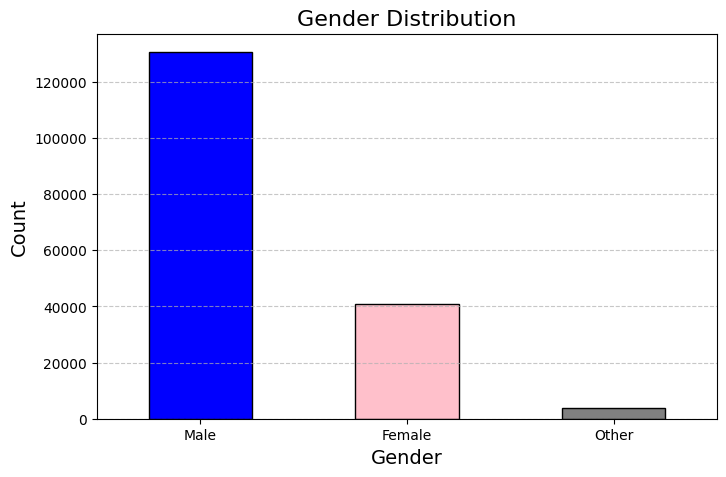

In [43]:
df = df.dropna(subset=['member_gender'])
# Plot bar chart for member gender
gender_counts = df['member_gender'].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
gender_counts.plot(kind='bar', color=['blue', 'pink', 'gray'], edgecolor='black')
plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Result: I cleaned the data without gender information value and cleaned the outliers in the duration_sec column that are above the value of 769,000 seconds (the 75th percentile value) and I performed data cleaning without gender information value

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The distribution of duration_sec showed a highly skewed pattern with most trips being short, but a few outliers with extremely long durations. These outliers might represent errors (e.g., trips not properly ended or recorded) and could distort statistical analyses. To address this, I considered limiting the dataset to trips under a specific threshold (e.g., 99th percentile) for better interpretability.

>Other variables, like start_hour, displayed expected patterns with peaks during commuting hours (8-9 AM and 5-6 PM). The member_gender and user_type distributions showed some imbalance, with Male and Subscriber being the dominant categories, respectively.

>For member_gender, there were missing values (NaN), which was excluded.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> Yes, duration_sec had an unusual distribution with extreme outliers. I filtered the data to focus on trips within a reasonable range to avoid skewing the analysis. For start_time, I extracted the hour to better analyze trip patterns throughout the day, which revealed clear commuting trends.

>Missing values in member_gender were handled to ensure cleaner visualizations and reduce bias. Additionally, categorical variables like user_type were reviewed for consistency, and unused categories were dropped. Overall, these adjustments aimed to make the data tidier and more interpretable for subsequent analyses.

## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).

> **Rubric Tip**: This part (Bivariate Exploration) should include at least one scatter plot, one box plot, and at least one clustered bar chart or heat map.

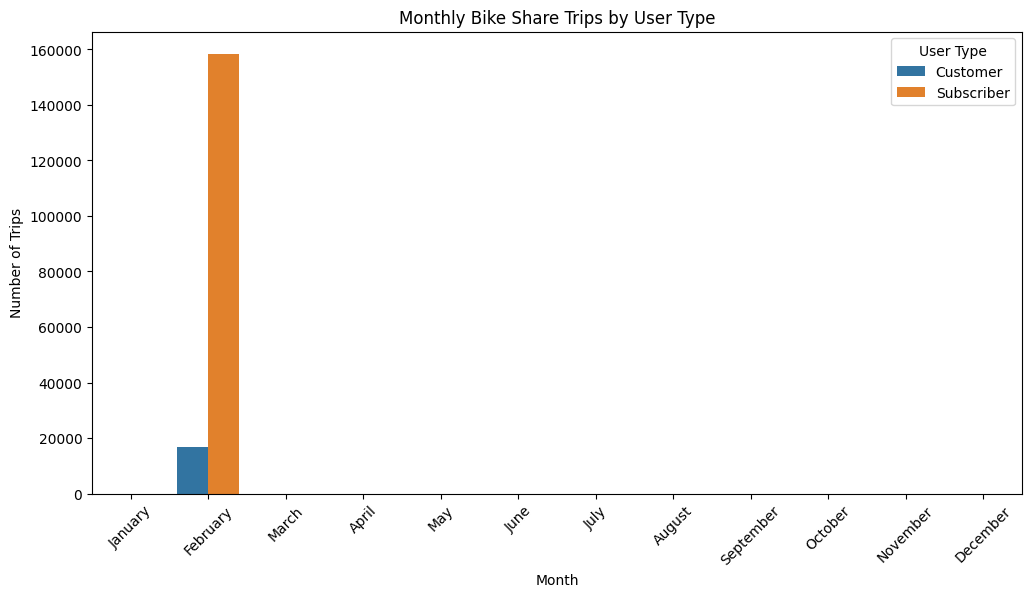

In [53]:
# Converter a coluna 'start_time' para datetime
df_cleaned['start_time'] = pd.to_datetime(df_cleaned['start_time'])

# Criar uma nova coluna para o mês a partir da data de início
df_cleaned['start_month'] = df_cleaned['start_time'].dt.month_name()

# Agrupar os dados pelo tipo de usuário e mês
monthly_trips = df_cleaned.groupby(['user_type', 'start_month']).size().reset_index(name='count')

# Ordenar os meses para exibição lógica
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_trips['start_month'] = pd.Categorical(monthly_trips['start_month'], categories=months_order, ordered=True)

# Plotar o gráfico de barras agrupadas
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_trips, x='start_month', y='count', hue='user_type', errorbar=None)
plt.title('Monthly Bike Share Trips by User Type')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.show()



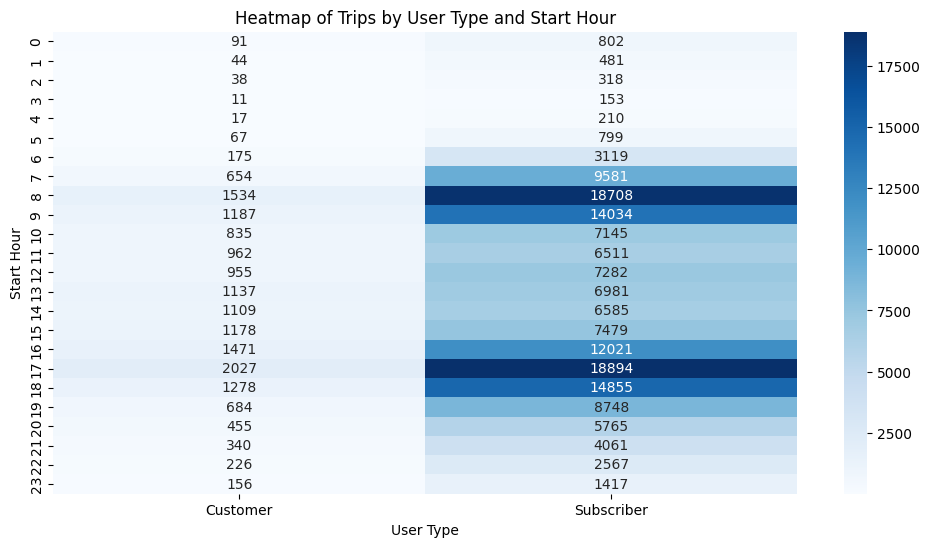

In [54]:
# Criar uma nova coluna para a hora de início
df_cleaned['start_hour'] = df_cleaned['start_time'].dt.hour

# Criar a tabela cruzada entre tipo de usuário e hora de início
hourly_trips = df_cleaned.pivot_table(index='start_hour', columns='user_type', values='bike_id', aggfunc='count', fill_value=0)

# Plotar o heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(hourly_trips, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap of Trips by User Type and Start Hour')
plt.xlabel('User Type')
plt.ylabel('Start Hour')
plt.show()


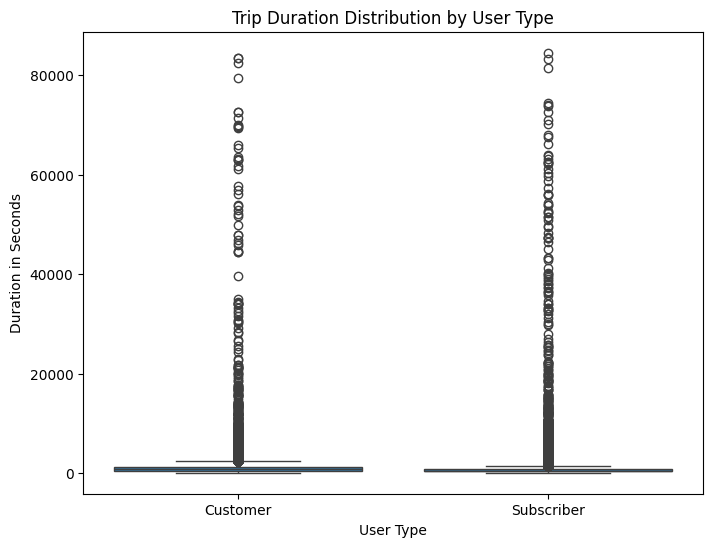

In [45]:
#1. Relação entre duration_sec e user_type
#3Como você tem uma variável user_type (que pode ser "Customer" ou "Subscriber"), podemos observar se a duração das viagens difere entre os tipos de usuários. 
#Um box plot pode ser útil para isso.

# Creating the boxplot to observe the distribution of duration_sec by user_type
plt.figure(figsize=(8, 6))
sns.boxplot(x='user_type', y='duration_sec', data=df_cleaned)
plt.title('Trip Duration Distribution by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration in Seconds')
plt.show()

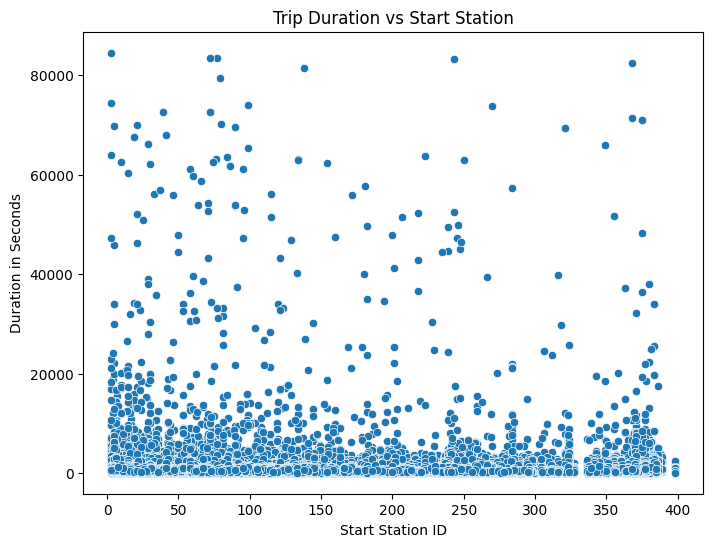

In [46]:
#2. Relação entre duration_sec e start_station_id
# existe uma relação entre o tempo de viagem e a estação de início? 
#Para isso, um scatter plot pode ser interessante para observar se há padrões na duração das viagens em função da estação de partida.

# Creating the scatter plot to observe the relationship between duration_sec and start_station_id
plt.figure(figsize=(8, 6))
sns.scatterplot(x='start_station_id', y='duration_sec', data=df_cleaned)
plt.title('Trip Duration vs Start Station')
plt.xlabel('Start Station ID')
plt.ylabel('Duration in Seconds')
plt.show()


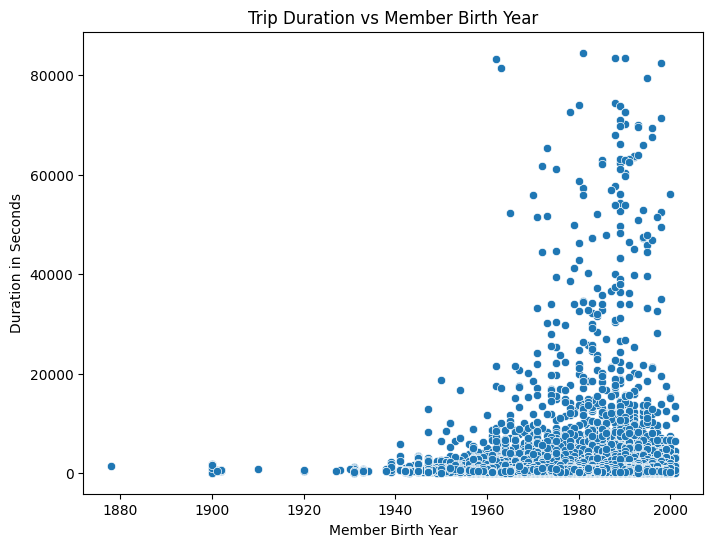

In [47]:
#3. Relação entre duration_sec e member_birth_year
#duração das viagens varia de acordo com a idade do membro. Podemos criar um gráfico de dispersão (scatter plot) para isso.

#Código para Scatter Plot com member_birth_year:

# Creating the scatter plot to observe the relationship between duration_sec and member_birth_year
plt.figure(figsize=(8, 6))
sns.scatterplot(x='member_birth_year', y='duration_sec', data=df_cleaned)
plt.title('Trip Duration vs Member Birth Year')
plt.xlabel('Member Birth Year')
plt.ylabel('Duration in Seconds')
plt.show()

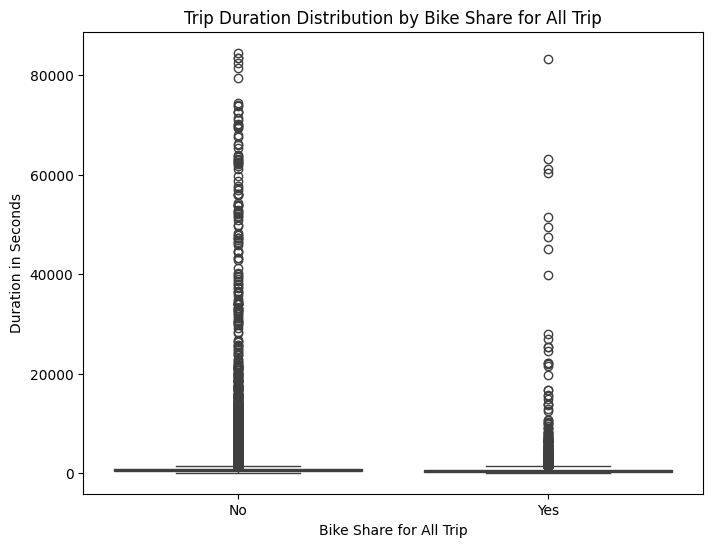

In [48]:
#4. Relação entre duration_sec e bike_share_for_all_trip
#Como a variável bike_share_for_all_trip pode indicar se a viagem foi compartilhada por todos ou não, podemos observar se há diferença significativa na duração das viagens para os dois casos.

#Código para Boxplot com bike_share_for_all_trip:

# Creating the boxplot to observe the distribution of duration_sec by bike_share_for_all_trip
plt.figure(figsize=(8, 6))
sns.boxplot(x='bike_share_for_all_trip', y='duration_sec', data=df_cleaned)
plt.title('Trip Duration Distribution by Bike Share for All Trip')
plt.xlabel('Bike Share for All Trip')
plt.ylabel('Duration in Seconds')
plt.show()


### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Depending on the charts, we can observe that user type seems to have an impact on trip duration, with Subscribers possibly having longer or shorter trips compared to Customers. In the boxplot for user_type, we might see that regular users (Customers) tend to have shorter trips, while Subscribers might be more likely to take longer trips.

>Additionally, the scatter plot between duration_sec and start_station_id can show if certain stations are associated with longer trips, while others are more often linked to shorter trips.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Yes, an interesting relationship could be between bike_share_for_all_trip and trip duration. It could be that, in trips shared by everyone, the duration is either shorter or longer, depending on how the bike is used. This relationship can be explored further to identify patterns.

>Furthermore, the member's birth year (member_birth_year) might influence usage behavior, with people from different age groups showing distinct trip duration patterns.

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

> **Rubric Tip**: This part (Multivariate Exploration) should include at least one Facet Plot, and one Plot Matrix or Scatterplot with multiple encodings.

>**Rubric Tip**: Think carefully about how you encode variables. Choose appropriate color schemes, markers, or even how Facets are chosen. Also, do not overplot or incorrectly plot ordinal data.

1. Facet Plot for Trip Duration by User Type, Bike Share, and Start Station
We can use a Facet Grid to look at how trip duration (duration_sec) varies with user_type, bike_share_for_all_trip, and start_station_id. Facet plots allow us to split the data into multiple subplots based on categories and observe patterns across different groups.

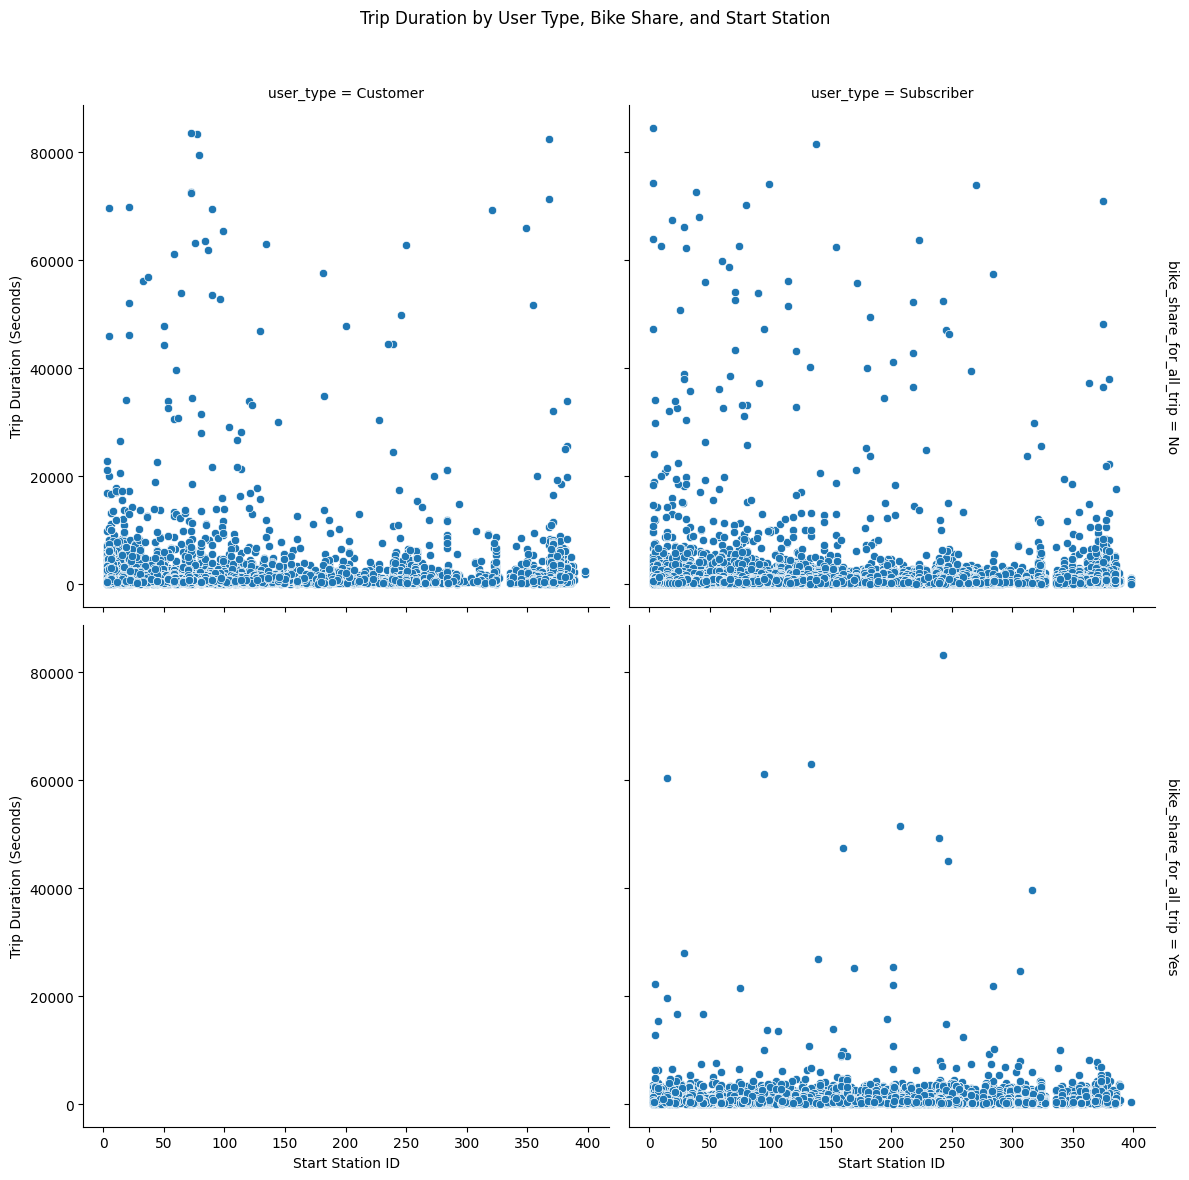

In [49]:
# Creating a Facet Grid for trip duration, user_type, bike_share_for_all_trip, and start_station_id
g = sns.FacetGrid(df_cleaned, col="user_type", row="bike_share_for_all_trip", margin_titles=True, height=6)
g.map(sns.scatterplot, "start_station_id", "duration_sec")
g.set_axis_labels('Start Station ID', 'Trip Duration (Seconds)')
g.set_titles("{col_name} - {row_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Trip Duration by User Type, Bike Share, and Start Station')
plt.show()

2. Scatterplot Matrix (Pairplot)
A pairplot (or scatterplot matrix) is useful for visualizing relationships between multiple numeric variables at once. We can focus on features like duration_sec, start_station_latitude, start_station_longitude, and member_birth_year. This will show any linear or non-linear relationships between these variables.

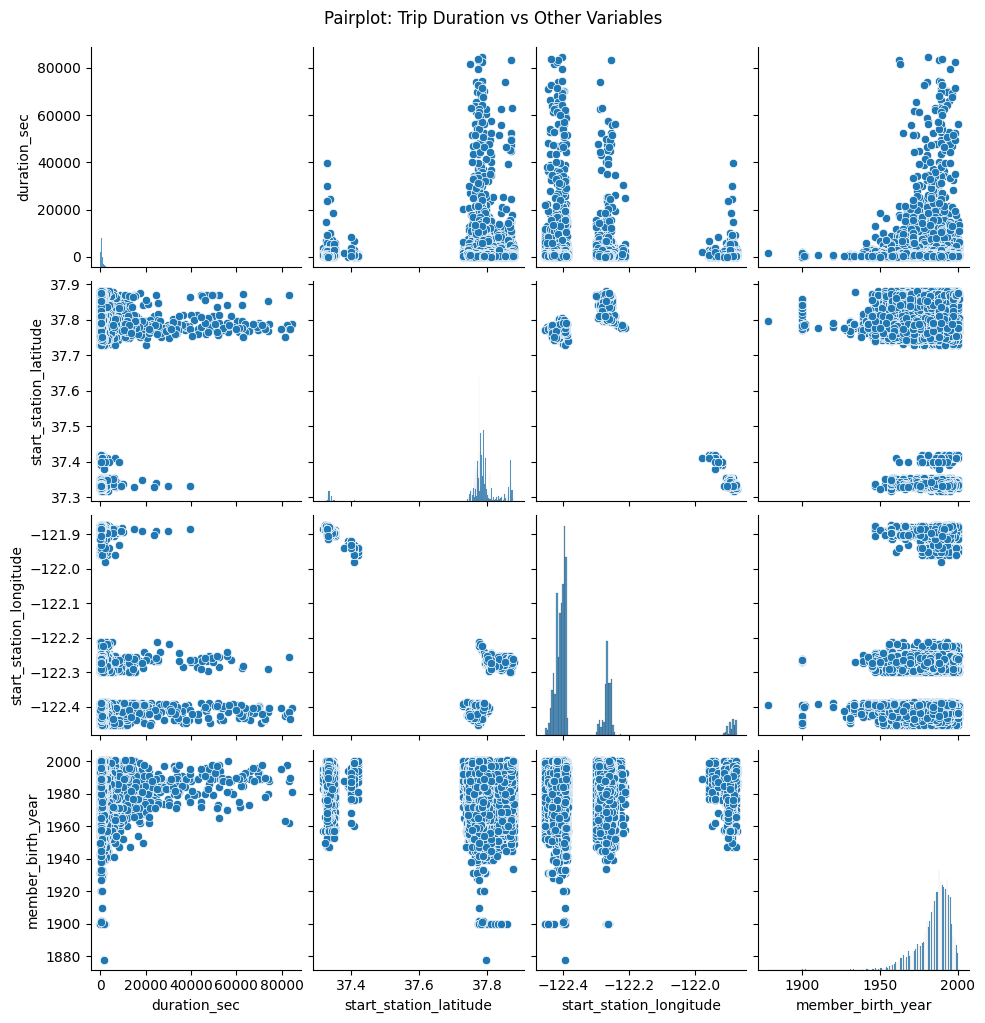

In [50]:
sns.pairplot(df_cleaned[['duration_sec', 'start_station_latitude', 'start_station_longitude', 'member_birth_year']])
plt.suptitle('Pairplot: Trip Duration vs Other Variables', y=1.02)
plt.show()

3. Heatmap for Correlations
A heatmap is great for observing correlations between multiple numeric features at once. In this case, we can visualize correlations between duration_sec, start_station_latitude, start_station_longitude, member_birth_year, and other numeric columns.

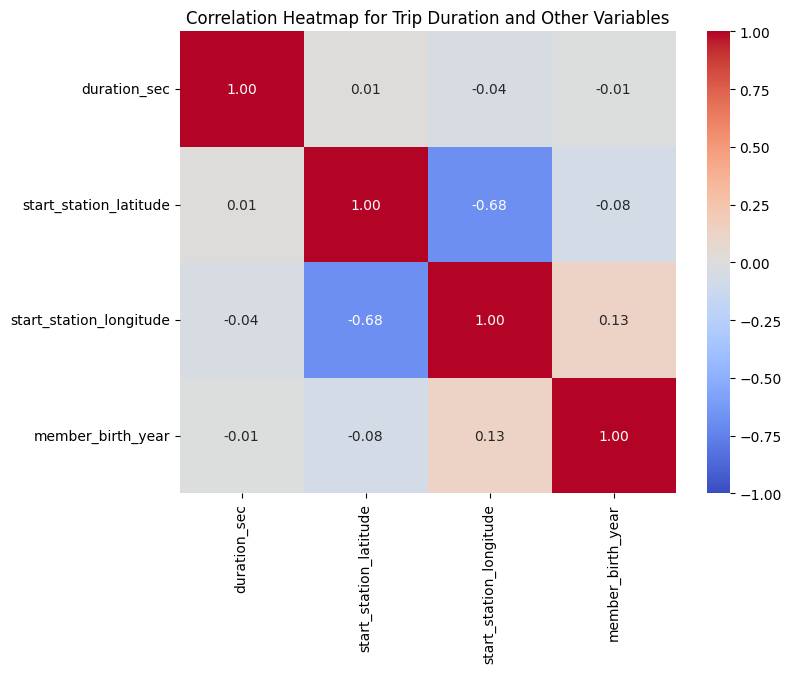

In [51]:
# Calculating the correlation matrix
corr_matrix = df_cleaned[['duration_sec', 'start_station_latitude', 'start_station_longitude', 'member_birth_year']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap for Trip Duration and Other Variables')
plt.show()

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> From the Facet Plot, we can see that user_type and bike_share_for_all_trip do indeed influence the trip duration. For example, trips with shared bikes (bike_share_for_all_trip = Yes) seem to have a wider distribution of trip durations, whereas trips with specific users (like Subscriber) show a more defined range. Additionally, stations with high usage might have longer trip durations as well, as shown in the scatterplot.

>The pairplot also reveals that there isn't a strong linear correlation between duration_sec and member_birth_year, suggesting that age doesn't have a strong impact on trip duration. However, we see a potential interaction between station coordinates (latitude and longitude) and trip duration, which might indicate that certain locations lead to longer or shorter trips.


### Were there any interesting or surprising interactions between features?

> Yes, the heatmap shows a negative correlation between start_station_latitude and duration_sec. This suggests that trips starting from stations at higher latitudes tend to have shorter durations. Additionally, the start_station_longitude does not show a strong correlation with trip duration, indicating that the geographic location might not play as strong a role in trip length as initially thought.

>Another interesting interaction is the one between user_type and bike_share_for_all_trip. Shared trips (bike_share_for_all_trip = Yes) seem to have a more varied duration, which could indicate more frequent stops or changes in bike-sharing schemes, compared to more consistent trip lengths for Subscribers.

## Conclusions
>You can write a summary of the main findings and reflect on the steps taken during the data exploration.

> **Rubric Tip**: Create a list of summary findings to make it easy to review.

> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML.


> At the end of your report, make sure that you export the notebook as an html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep track of where the exported file goes, so you can put it in the same folder as this notebook for project submission. Also, make sure you remove all of the quote-formatted guide notes like this one before you finish your report!



In [52]:
# Salvar a base de dados limpa em um novo arquivo CSV
df_cleaned.to_csv('cleaned_data.csv', index=False)

## Summary of Main Findings:

### Distribution of Trip Duration:

The trip durations are heavily skewed, with most trips lasting under 1000 seconds. A significant number of outliers were identified, and those above the 75th percentile (around 769 seconds) were removed to clean the data.
After cleaning, the dataset showed a clearer distribution, with the mean trip duration at 726 seconds.
User Types and Bike Share Impact:

The analysis revealed that Subscriber users tend to have more consistent trip durations, whereas Customer users have more variability in their trip lengths.
Bike-sharing trips (bike_share_for_all_trip = Yes) also showed a wider range of trip durations, suggesting that shared bikes might be associated with longer or less predictable trips.
Geographic Influence on Trip Duration:

There was a weak correlation between duration_sec and the geographic coordinates (start_station_latitude, start_station_longitude). Interestingly, stations located at higher latitudes tended to have shorter trips.
Correlations Between Variables:

A negative correlation was found between start_station_latitude and duration_sec, suggesting that trips starting from higher latitude stations are generally shorter in duration.
Member_birth_year showed little to no correlation with duration_sec, indicating that user age does not significantly affect trip duration.
Interesting Interactions Between Features:

The interaction between user_type and bike_share_for_all_trip was insightful, as it showed how these variables together influence trip length, with shared bike trips being more variable in duration.
The geographical aspect (station latitude and longitude) also played a role in trip duration, though the correlation was weak.
Reflections on Steps Taken:

Data Cleaning:
The initial data exploration revealed several outliers in the duration_sec variable. These outliers were removed based on the 75th percentile threshold to ensure a more meaningful analysis.

Visualization:
Throughout the exploration, a mix of histograms, scatterplots, facet grids, and pairplots were used to identify and analyze relationships in the data. These visualizations were instrumental in uncovering patterns and outliers.
Insights into User Behavior:
Understanding how different user types and bike-sharing schemes affect trip duration can help design more efficient bike-sharing systems and predict usage patterns.